Checking for out-of-distribution data

Nanta June, 2025

# Solv_GNN_SSD data: combine Exp and Aug data

## DMF as solvent

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [2]:
dfexp = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/Exp-DB.csv')
print(dfexp.shape)
dfexp.head()

(23996, 11)


,solute,solvent,logS,DGsolv,Reference (DOI),Comments,can_smiles_solute,can_smiles_solvent,concat_smiles,is_chonps_halogens,index
0,B#N,O,-6.39,NaN,10.1038/s41597-019-0151-1,"From AqSolDB, Density and temp are aproximated...",B#N,O,B#N.O,True,1
1,B12B3B4B1C234,O,-4.74,NaN,10.1038/s41597-019-0151-1,"From AqSolDB, Density and temp are aproximated...",B12B3B4B1C234,O,B12B3B4B1C234.O,True,2
2,Br,CCCC,NaN,-1.23,10.1016/j.cej.2021.129307,['CompSol Binary (entry number=34224)'],Br,CCCC,Br.CCCC,True,3
3,Br,CCCCCC,NaN,-1.19,10.1016/j.cej.2021.129307,['CompSol Binary (entry number=45365)'],Br,CCCCCC,Br.CCCCCC,True,4
4,Br,CCCCCCCC,NaN,-1.11,10.1016/j.cej.2021.129307,['CompSol Binary (entry number=54328)'],Br,CCCCCCCC,Br.CCCCCCCC,True,5


In [3]:
print(len(dfexp['solute'].unique()))
print(len(dfexp['solvent'].unique()))
print(len(dfexp[dfexp['DGsolv'].isna()]))
print(len(dfexp[~dfexp['DGsolv'].isna()]))
print(len(dfexp[~dfexp['DGsolv'].isna()]['can_smiles_solute'].unique()))
print(len(dfexp[~dfexp['DGsolv'].isna()]['can_smiles_solvent'].unique()))

13099
1598
12359
11637
2275
1443


In [4]:
len(dfexp[(~dfexp['DGsolv'].isna()) & (dfexp['can_smiles_solvent']=='CN(C)C=O')])

161

In [5]:
# print(dfexp[dfexp['can_smiles_solvent'].str.contains('CN')]['can_smiles_solvent'].unique())
print(dfexp[dfexp['solvent']=="C(=O)N(C)C"]["can_smiles_solvent"].unique())


['CN(C)C=O']


In [6]:
# select only one with DMF as solvent
dfexp = dfexp[(~dfexp['DGsolv'].isna()) & (dfexp['can_smiles_solvent'] == 'CN(C)C=O')]
print(dfexp.shape)
dfexp.head()

(161, 11)


,solute,solvent,logS,DGsolv,Reference (DOI),Comments,can_smiles_solute,can_smiles_solvent,concat_smiles,is_chonps_halogens,index
103,C1=CC=C(C=C1)Br,C(=O)N(C)C,NaN,-6.21,10.1016/j.cej.2021.129307,"['Abraham Paper (A20)', 'Abraham Paper (A5)']",Brc1ccccc1,CN(C)C=O,Brc1ccccc1.CN(C)C=O,True,104
121,C#C,C(=O)N(C)C,NaN,-1.75,10.1016/j.cej.2021.129307,"['Abraham Paper (A20)', 'Abraham Paper (A5)']",C#C,CN(C)C=O,C#C.CN(C)C=O,True,122
156,CC#C,C(=O)N(C)C,NaN,-2.49,10.1016/j.cej.2021.129307,"['Abraham Paper (A20)', 'Abraham Paper (A5)', ...",C#CC,CN(C)C=O,C#CC.CN(C)C=O,True,157
189,C=CC#C,C(=O)N(C)C,NaN,-3.28,10.1016/j.cej.2021.129307,"['Abraham Paper (A20)', 'Abraham Paper (A5)', ...",C#CC=C,CN(C)C=O,C#CC=C.CN(C)C=O,True,190
201,CCC#C,C(=O)N(C)C,NaN,-2.92,10.1016/j.cej.2021.129307,"['Abraham Paper (A20)', 'Abraham Paper (A5)']",C#CCC,CN(C)C=O,C#CCC.CN(C)C=O,True,202


In [ ]:
# dfexp.to_csv('/home/nanta/Solv_GNN_SSD/data/Exp-DB-DMF.csv', index=False)

In [8]:
dfaug = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/Aug-DBs/Aug-DB1.csv')
print(dfaug.shape)
dfaug = dfaug[dfaug['can_smiles_solvent'] == 'CN(C)C=O']
print(dfaug.shape)

(183432, 11)
(490, 11)


In [9]:
sum_aug = 0
for i in range(2, 40):
    dfaug_i = pd.read_csv(f'/home/nanta/Solv_GNN_SSD/data/Aug-DBs/Aug-DB{i}.csv')
    print(dfaug_i.shape)
    sum_aug += dfaug_i.shape[0]
    dfaug_i = dfaug_i[dfaug_i['can_smiles_solvent'] == 'CN(C)C=O']
    print(dfaug_i.shape)
    dfaug = pd.concat([dfaug, dfaug_i], ignore_index=True)

print(sum_aug)

(65833, 11)
(202, 11)
(41560, 11)
(110, 11)
(34013, 11)
(128, 11)
(32474, 11)
(95, 11)
(34611, 11)
(84, 11)
(34421, 11)
(87, 11)
(35701, 11)
(81, 11)
(34792, 11)
(95, 11)
(35617, 11)
(119, 11)
(34134, 11)
(118, 11)
(31074, 11)
(108, 11)
(30626, 11)
(142, 11)
(29906, 11)
(100, 11)
(26324, 11)
(71, 11)
(27968, 11)
(104, 11)
(21448, 11)
(76, 11)
(23263, 11)
(95, 11)
(16959, 11)
(71, 11)
(19311, 11)
(86, 11)
(14931, 11)
(63, 11)
(15951, 11)
(57, 11)
(12215, 11)
(59, 11)
(10901, 11)
(43, 11)
(12160, 11)
(72, 11)
(8927, 11)
(37, 11)
(7142, 11)
(24, 11)
(8521, 11)
(31, 11)
(7705, 11)
(30, 11)
(6346, 11)
(20, 11)
(5603, 11)
(21, 11)
(5605, 11)
(33, 11)
(4522, 11)
(22, 11)
(3708, 11)
(17, 11)
(3168, 11)
(6, 11)
(3664, 11)
(21, 11)
(3280, 11)
(8, 11)
(3233, 11)
(22, 11)
(2961, 11)
(9, 11)
750578


In [5]:
print(sum_aug + 183432)

934010


In [10]:
print(dfaug.shape)

(3057, 11)


In [ ]:
# dfaug.to_csv('/home/nanta/Solv_GNN_SSD/data/Aug-DB-DMF.csv', index=False)

In [11]:
# combine the two dataframes
df = pd.concat([dfexp, dfaug], ignore_index=True)

# remove duplicates
df = df.drop_duplicates(subset=['solute'])
print(df.shape)


(3218, 15)


In [12]:
df.to_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent.csv', index=False)

## All solutes

In [51]:
dfexp = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/Exp-DB.csv')
print(dfexp.shape)
dfexp.head()

(23996, 11)


,solute,solvent,logS,DGsolv,Reference (DOI),Comments,can_smiles_solute,can_smiles_solvent,concat_smiles,is_chonps_halogens,index
0,B#N,O,-6.39,NaN,10.1038/s41597-019-0151-1,"From AqSolDB, Density and temp are aproximated...",B#N,O,B#N.O,True,1
1,B12B3B4B1C234,O,-4.74,NaN,10.1038/s41597-019-0151-1,"From AqSolDB, Density and temp are aproximated...",B12B3B4B1C234,O,B12B3B4B1C234.O,True,2
2,Br,CCCC,NaN,-1.23,10.1016/j.cej.2021.129307,['CompSol Binary (entry number=34224)'],Br,CCCC,Br.CCCC,True,3
3,Br,CCCCCC,NaN,-1.19,10.1016/j.cej.2021.129307,['CompSol Binary (entry number=45365)'],Br,CCCCCC,Br.CCCCCC,True,4
4,Br,CCCCCCCC,NaN,-1.11,10.1016/j.cej.2021.129307,['CompSol Binary (entry number=54328)'],Br,CCCCCCCC,Br.CCCCCCCC,True,5


# Data from filter 2 in Redox_mediator_screening

In [2]:
dff2 = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter2.csv.gz', compression='gzip')
print(dff2.shape)

/tmp/ipykernel_2749487/2165164651.py:1: DtypeWarning: Columns (32,39) have mixed types. Specify dtype option on import or set low_memory=False.
  dff2 = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter2.csv.gz', compression='gzip')


(635212, 49)


In [15]:
dff2.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'CID', 'cmpdname', 'cmpdsynonym', 'mw',
       'mf', 'polararea', 'complexity', 'xlogp', 'heavycnt', 'hbonddonor',
       'hbondacc', 'rotbonds', 'inchi', 'smiles', 'inchikey', 'iupacname',
       'exactmass', 'monoisotopicmass', 'charge', 'covalentunitcnt',
       'isotopeatomcnt', 'totalatomstereocnt', 'definedatomstereocnt',
       'undefinedatomstereocnt', 'totalbondstereocnt', 'definedbondstereocnt',
       'undefinedbondstereocnt', 'pclidcnt', 'gpidcnt', 'gpfamilycnt',
       'meshheadings', 'annothits', 'annothitcnt', 'aids', 'cidcdate',
       'sidsrcname', 'depcatg', 'annotation', 'B3LYPLUMO', 'PM6LUMO',
       'B3LYPHOMO', 'PM6HOMO', 'commercial_avail', 'can_smiles_solute',
       'can_smiles_solvent', 'DGsolv', 'solubility_predicted'],
      dtype='object')

# Out-of-distribution assessment

In [13]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)

train_fps = np.array([np.array(mfpgen.GetFingerprint(Chem.MolFromSmiles(smiles))) for smiles in df['solute'] if Chem.MolFromSmiles(smiles) is not None])
print(len(train_fps))


3218


In [ ]:
# take ~ 9 min
test_fps = np.array([np.array(mfpgen.GetFingerprint(Chem.MolFromSmiles(smiles))) for smiles in dff2['smiles'] if Chem.MolFromSmiles(smiles) is not None])
print(len(test_fps))

In [ ]:
# train_fps = np.array([np.array(fp) for fp in train_fps])
# test_fps = np.array([np.array(fp) for fp in test_fps])

In [17]:
# save the fingerprints
np.save('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/train_solute_fps.npy', train_fps)
# np.save('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/test_smiles_fps.npy', test_fps)

In [7]:
from rdkit import DataStructs

def tanimoto_distance(fp1, fp2):
    return 1 - DataStructs.TanimotoSimilarity(fp1, fp2)


In [26]:
# try samller set
train_fps_small = train_fps[:10]
# test_fps_small = test_fps[:10]

In [ ]:
# make all member in test_fps be np.array
# test_fps_small = np.array([np.array(fp) for fp in test_fps_small])
print(test_fps_small[0])

array([0, 0, 0, ..., 0, 0, 0])

## Training set

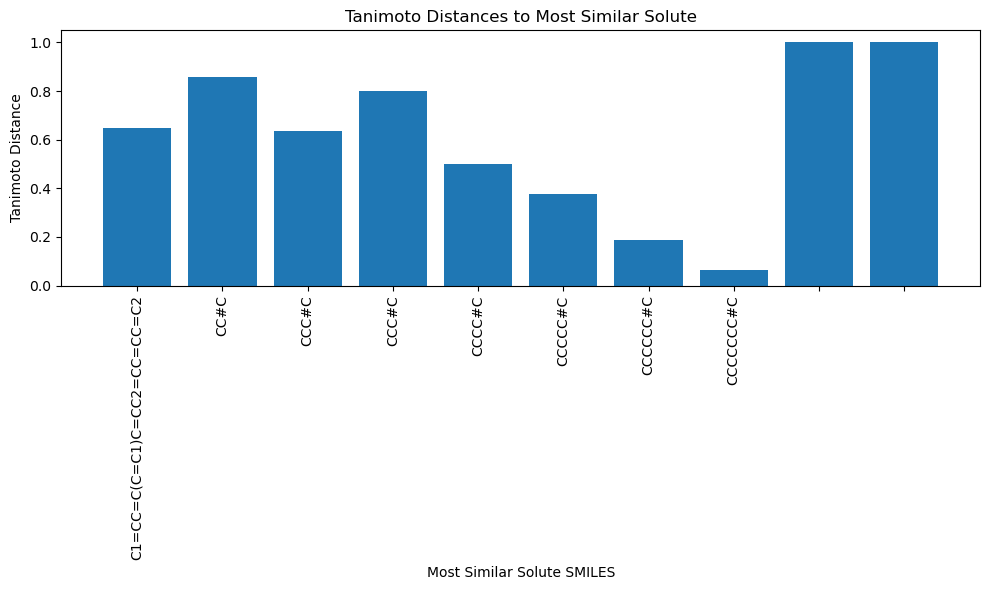

In [ ]:
from rdkit import DataStructs

nn_distances = []

# For each test_fp in test_fps_small, find the minimum distance and the most similar train_fp
min_distances = []
most_similar_smiles = []

# find the minimum distance within the train_fp
for i, train_fp1 in enumerate(train_fps_small):
    min_distance = 1.0
    best_smiles = None
    train_fp_rdkit1 = DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fp1)))

    for idx, train_fp2 in enumerate(train_fps_small[i+1:], start=i+1):
        train_fp_rdkit2 = DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fp2)))
        dist = tanimoto_distance(train_fp_rdkit1, train_fp_rdkit2)
        if dist < min_distance:
            min_distance = dist
            best_smiles = df.iloc[idx]['solute']
    min_distances.append(min_distance)
    most_similar_smiles.append(best_smiles)
    nn_distances.append(min_distance)


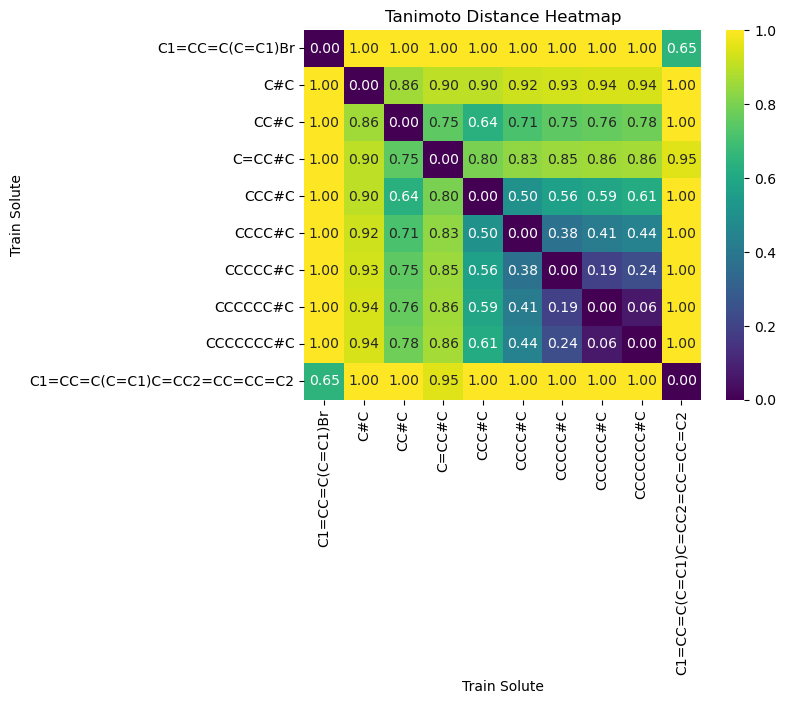

In [36]:
# plot heatmap of the distances
import seaborn as sns
import matplotlib.pyplot as plt
# Create a distance matrix
distance_matrix = np.zeros((len(train_fps_small), len(train_fps_small)))
for i in range(len(train_fps_small)):
    for j in range(len(train_fps_small)):
        if i != j:
            distance_matrix[i, j] = tanimoto_distance(
                DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fps_small[i]))),
                DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fps_small[j])))
            )
        else:
            distance_matrix[i, j] = 0.0  # Distance to itself is zero
sns.heatmap(distance_matrix, annot=True, fmt=".2f", cmap='viridis', xticklabels=df['solute'][:10], yticklabels=df['solute'][:10])
plt.title('Tanimoto Distance Heatmap')
plt.xlabel('Train Solute')
plt.ylabel('Train Solute')
plt.show()

In [ ]:
# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(range(len(nn_distances)), nn_distances, tick_label=most_similar_smiles)
plt.xlabel('Most Similar Solute SMILES')
plt.ylabel('Tanimoto Distance')
plt.title('Tanimoto Distances to Most Similar Solute')
plt.xticks(rotation=90)
plt.tight_layout()

## samples

In [9]:
# load the fingerprints
train_fps = np.load('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/train_solute_fps.npy')
test_fps = np.load('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/test_smiles_fps.npy')

df = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent.csv')


In [12]:
from rdkit import DataStructs
from tqdm import tqdm

train_fps_small = train_fps[:1000]
test_fps_small = test_fps[:1000]
nn_distances = []

# For each test_fp in test_fps_small, find the minimum distance and the most similar train_fp
min_distances = []
most_similar_smiles = []

for test_fp in tqdm(test_fps_small, desc="Processing test fingerprints"):
    min_distance = 1.0
    best_smiles = None
    test_fp_rdkit = DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, test_fp)))
    for idx, train_fp in enumerate(train_fps_small):
    # for idx, train_fp in enumerate(train_fps):
        train_fp_rdkit = DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fp)))
        dist = tanimoto_distance(test_fp_rdkit, train_fp_rdkit)
        if dist < min_distance:
            min_distance = dist
            best_smiles = df.iloc[idx]['solute']
    min_distances.append(min_distance)
    most_similar_smiles.append(best_smiles)
    nn_distances.append(min_distance)

# Add to dff2 (only for the first len(test_fps_small) rows)
dff2.loc[:len(test_fps_small)-1, 'nn_distance'] = min_distances
dff2.loc[:len(test_fps_small)-1, 'most_similar_train_solute'] = most_similar_smiles


Processing test fingerprints:  30%|███       | 301/1000 [01:00<02:21,  4.94it/s]


KeyboardInterrupt: 

Text(0.5, 0, 'Tanimoto Distance')

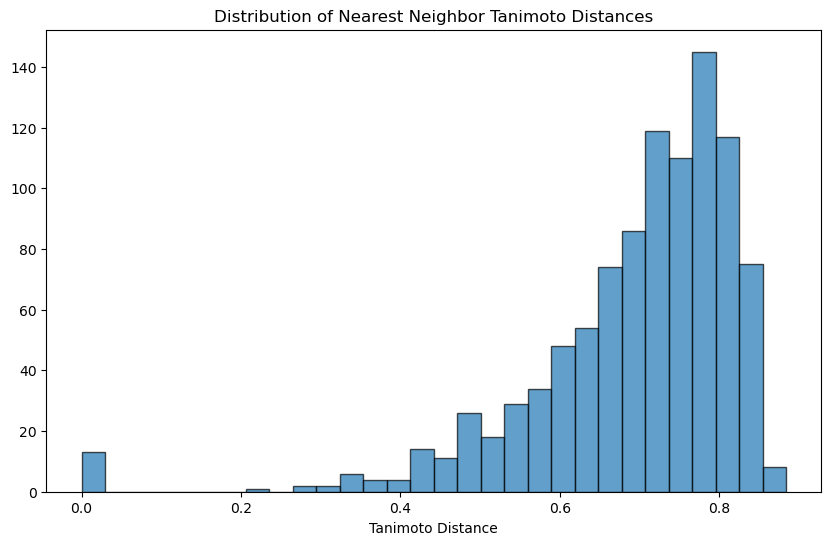

In [42]:
# plot the distances distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(nn_distances, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Nearest Neighbor Tanimoto Distances')
plt.xlabel('Tanimoto Distance')

In [43]:
dff2[dff2['nn_distance']<0.7].head()

,Unnamed: 0.1,Unnamed: 0,CID,cmpdname,cmpdsynonym,mw,mf,polararea,complexity,xlogp,...,PM6LUMO,B3LYPHOMO,PM6HOMO,commercial_avail,can_smiles_solute,can_smiles_solvent,DGsolv,solubility_predicted,nn_distance,most_similar_train_solute
2,2,2,14,7-[3-Hydroxy-5-oxo-2-(3-oxooct-1-enyl)cyclopen...,PD051112,352.50,C20H32O5,91.7,469.0,3.1,...,-0.375517,-6.547059,-10.190664,yes,CCCCCC(=O)C=CC1C(CC(=O)C1CCCCCCC(=O)O)O,CN(C)C=O,NaN,-24.575998,0.604651,CCCCCCC(O)=O
3,3,3,19,"2,3-Dihydroxybenzoic acid","2,3-Dihydroxybenzoic acid|303-38-8|Pyrocatechu...",154.12,C7H6O4,77.8,157.0,1.2,...,-1.232132,-6.081745,-9.339219,yes,C1=CC(=C(C(=C1)O)O)C(=O)O,CN(C)C=O,NaN,-15.041539,0.347826,C1=CC=C(C(=C1)C(=O)O)O
4,4,4,21,2-Aceto-2-hydroxybutanoate,Acetohydroxybutyrate|2-Aceto-2-hydroxybutanoat...,146.14,C6H10O4,74.6,163.0,-0.2,...,-0.470213,-7.453198,-10.849179,yes,CCC(C(=O)C)(C(=O)O)O,CN(C)C=O,NaN,-14.629997,0.565217,CCC(C)(C)C(O)=O
5,5,5,22,2-Hydroxy-2-methyl-3-oxobutanoic acid,2-Acetolactate|918-44-5|2-hydroxy-2-methyl-3-o...,132.11,C5H8O4,74.6,151.0,-0.7,...,-0.521098,-7.485852,-10.901425,yes,CC(=O)C(C)(C(=O)O)O,CN(C)C=O,NaN,-14.414878,0.636364,CCC(C)(C)C(O)=O
9,9,9,38,"4-Hydroxy-3,3-dimethyl-2-oxobutanoic acid","2-dehydropantoate|4-hydroxy-3,3-dimethyl-2-oxo...",146.14,C6H10O4,74.6,159.0,-0.1,...,-1.079748,-6.729376,-10.347673,yes,CC(C)(CO)C(=O)C(=O)O,CN(C)C=O,NaN,-13.372119,0.608696,CCC(C)(C)C(O)=O


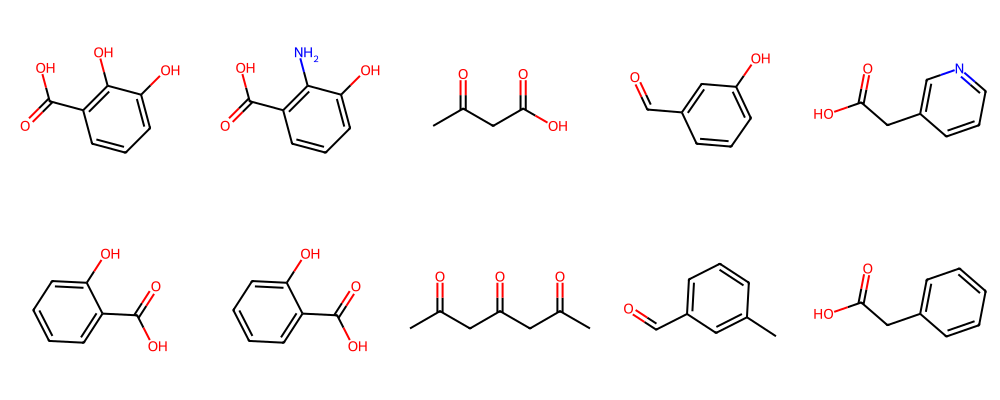

In [44]:
# rdkit draw dff2 smiles and most_similar_smiles
from rdkit.Chem import Draw
from rdkit import Chem

def draw_smiles(smiles_list, size=(200, 200), n=5):
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    return Draw.MolsToGridImage(mols, molsPerRow=n, subImgSize=size)

# Draw the first 5 smiles from dff2 and their most similar train solute smiles
# draw_smiles(dff2['smiles'][5:10].tolist() + dff2['most_similar_train_solute'][5:10].tolist(), size=(200, 200))
draw_smiles(dff2[dff2['nn_distance']<0.5]['smiles'].head().tolist() + dff2[dff2['nn_distance']<0.5]['most_similar_train_solute'].head().tolist(), size=(200, 200), n=5)


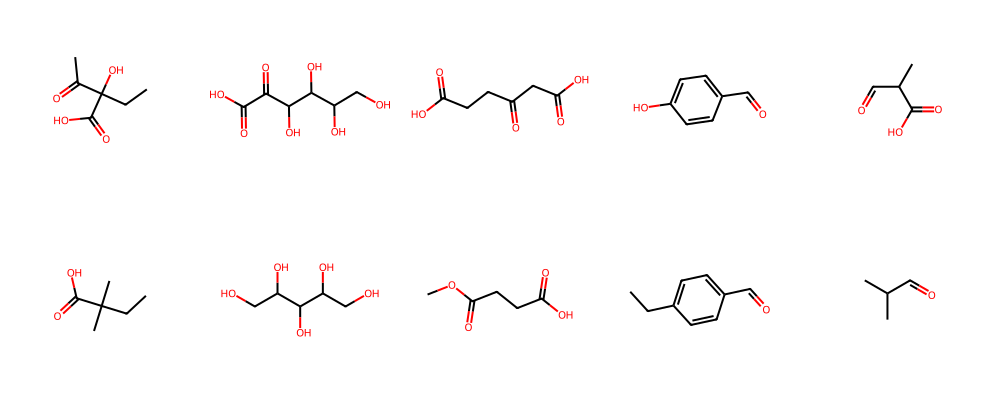

In [47]:
dftemp = dff2[(dff2['nn_distance']>0.5)& (dff2['nn_distance']<0.6)]
draw_smiles(dftemp['smiles'].head().tolist() + dftemp['most_similar_train_solute'].head().tolist(), size=(200, 200), n=5)


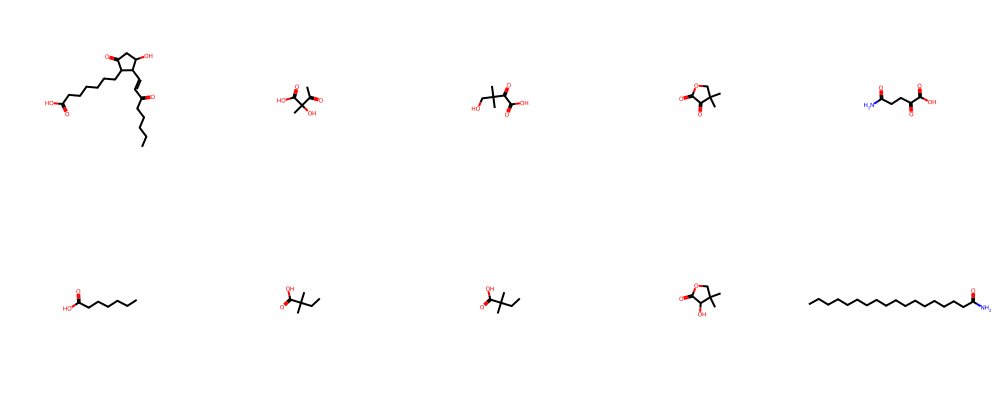

In [48]:
dftemp = dff2[(dff2['nn_distance']>0.6)& (dff2['nn_distance']<0.7)]
draw_smiles(dftemp['smiles'].head().tolist() + dftemp['most_similar_train_solute'].head().tolist(), size=(200, 200), n=5)


In [ ]:
# do nearest neighbor with the full dff2
# # too long
# nn_distances_full = []
# min_distances_full = []
# most_similar_smiles_full = []

# for test_fp in test_fps:
#     min_distance = 1.0
#     best_smiles = None
#     test_fp_rdkit = DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, test_fp)))
#     for idx, train_fp in enumerate(train_fps):
#         train_fp_rdkit = DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fp)))
#         dist = tanimoto_distance(test_fp_rdkit, train_fp_rdkit)
#         if dist < min_distance:
#             min_distance = dist
#             best_smiles = df.iloc[idx]['solute']
#     min_distances_full.append(min_distance)
#     most_similar_smiles_full.append(best_smiles)
#     nn_distances_full.append(min_distance)

# # Add to dff2 (for the full set)
# dff2['nn_distance'] = min_distances_full
# dff2['most_similar_train_solute'] = most_similar_smiles_full
# # Save the updated dff2
# dff2.to_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/filter2_with_nn.csv.gz', compression='gzip', index=False)

## [Deprecated] clustering train data

### KMeans

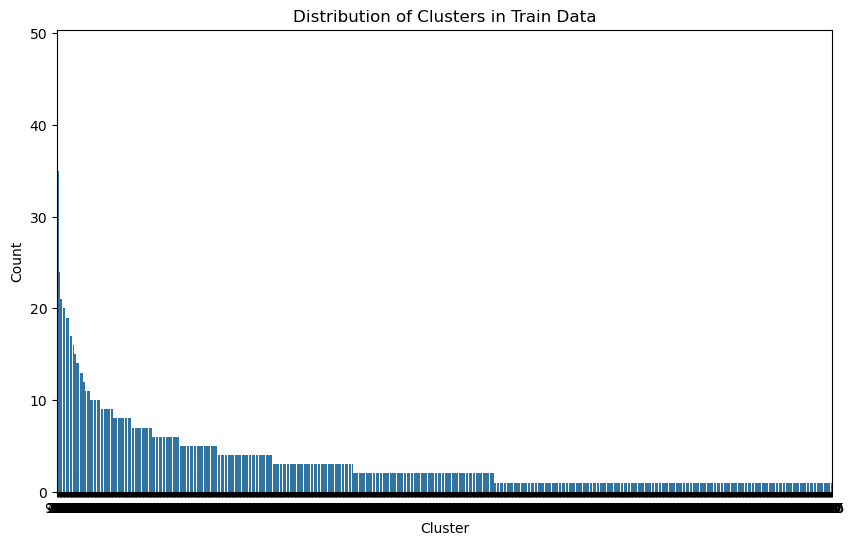

In [13]:
# cluster the train_fps using KMeans
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=1000, random_state=42)
kmeans.fit(train_fps)
# Add cluster labels to the train dataframe
df['cluster'] = kmeans.labels_
# Save the updated train dataframe with clusters
# df.to_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent_with_clusters.csv', index=False)
# Add cluster labels to the dff2 dataframe
# dff2['cluster'] = kmeans.predict(test_fps)
# # Save the updated dff2 dataframe with clusters
# dff2.to_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/filter2_with_nn_and_clusters.csv.gz', compression='gzip', index=False)
# Plot the distribution of clusters
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cluster', order=df['cluster'].value_counts().index)
plt.title('Distribution of Clusters in Train Data')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

In [14]:
# pca plot of the train_fps
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(train_fps)


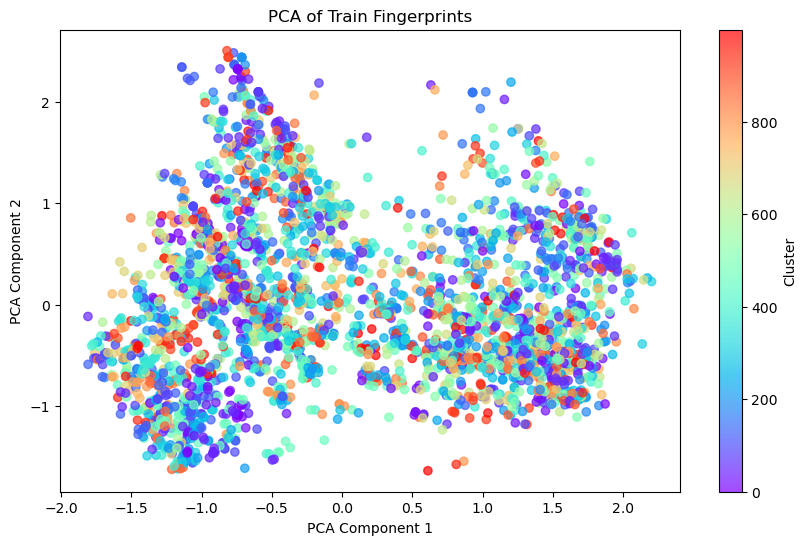

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df['cluster'], cmap='rainbow', alpha=0.7)
plt.title('PCA of Train Fingerprints')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

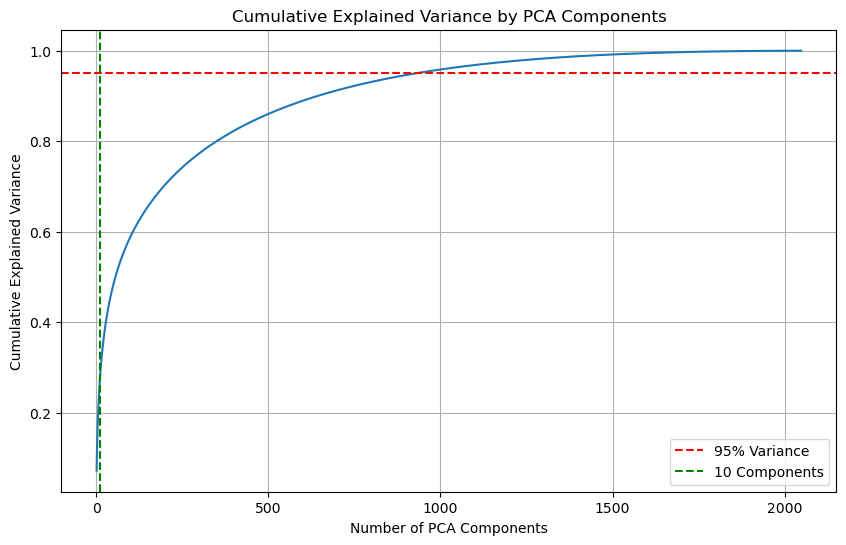

In [27]:
# plot pca to find number of clusters using percentage of variance explained
import matplotlib.pyplot as plt
pca = PCA()
pca.fit(train_fps)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_))
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axvline(x=10, color='g', linestyle='--', label='10 Components')
plt.legend()
plt.show()

In [16]:
# get the molecules at the center of each cluster
from rdkit import Chem
def get_cluster_centers(train_fps, labels):
    centers = []
    for cluster in np.unique(labels):
        cluster_fps = train_fps[labels == cluster]
        center_fp = np.mean(cluster_fps, axis=0)
        centers.append(center_fp)
    return np.array(centers)
cluster_centers = get_cluster_centers(train_fps, df['cluster'].values)

In [17]:
cluster_centers[0]

array([0.   , 0.625, 0.   , ..., 0.   , 0.   , 0.   ])

In [ ]:
df[df['cluster'] == 00].head()

,solute,solvent,logS,DGsolv,Reference (DOI),Comments,can_smiles_solute,can_smiles_solvent,concat_smiles,is_chonps_halogens,index,DGsolv_cosmo,Atom_bond_type_overlap_with_exp,AE,Signed_Err,cluster
993,O=C(NC1CCCC1)Nc2ccccc2,CN(C)C=O,NaN,-16.679829,NaN,NaN,O=C(Nc1ccccc1)NC1CCCC1,CN(C)C=O,O=C(Nc1ccccc1)NC1CCCC1.CN(C)C=O,NaN,665300,-16.696241,Y,0.016412,0.016412,800


### Nearest neighbors

In [36]:
train_fps_small = train_fps[:1000]

In [38]:
import tqdm
# calculate nearest neighbor distances for all train_fps
# 3 min run
def calculate_nn_distances(train_fps):
    nn_distances = []
    nn_molecules = []
    for i, train_fp1 in enumerate(tqdm.tqdm(train_fps, desc="Calculating NN distances")):
        min_distance = 1.0
        nearest_molecule = None
        for j, train_fp2 in enumerate(train_fps):
            if i != j:
                dist = tanimoto_distance(
                    DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fp1))),
                    DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, train_fp2)))
                )
                if dist < min_distance:
                    min_distance = dist
                    nearest_molecule = df.iloc[j]['solute']
        nn_molecules.append(nearest_molecule)
        nn_distances.append(min_distance)
    return np.array(nn_distances)
# nn_distances = calculate_nn_distances(train_fps)
nn_distances = calculate_nn_distances(train_fps_small)

Calculating NN distances: 100%|██████████| 1000/1000 [07:23<00:00,  2.25it/s]


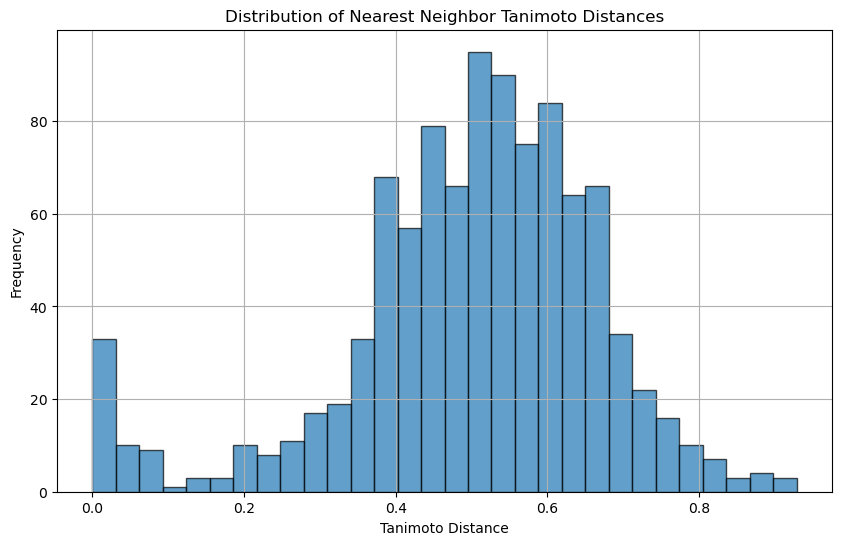

In [39]:
# plot the distribution of nearest neighbor distances
plt.figure(figsize=(10, 6))
plt.hist(nn_distances, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Nearest Neighbor Tanimoto Distances')
plt.xlabel('Tanimoto Distance')
plt.ylabel('Frequency')
plt.grid()
plt.show()

## Butina clustering

In [3]:
# load data
train_fps = np.load('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/train_solute_fps.npy')
test_fps = np.load('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/test_smiles_fps.npy')

df = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent.csv')
print(len(train_fps), len(test_fps), df.shape)

3218 635212 (3218, 15)


### Cluster together

The dataset is too big 600K molecules. Cannot do in one go.
Need to chunk to cluster then cluster again and again.

Below do only ~50000 molecules (combined train and test data)

In [21]:
combined_fps = np.concatenate((train_fps, test_fps[:50000]), axis=0)

In [22]:
print(len(train_fps), len(test_fps), len(combined_fps) )

3218 635212 53218


In [23]:
combined_fps_small  = combined_fps[:50000]

In [24]:
# Butina clustering of train_fps
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from tqdm import tqdm

def tanimoto_distance(fp1, fp2):
    return 1 - DataStructs.TanimotoSimilarity(fp1, fp2)

def calculate_distance_matrix(fps):
    # Calculate the upper triangle of the distance matrix (excluding diagonal)
    dists = []
    nfps = len(fps)
    for i in tqdm(range(1, nfps), desc="Calculating distance matrix"):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - x for x in sims])
    return dists

# combined_fps_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in tqdm(combined_fps, desc="Converting fingerprints to RDKit format")]
combined_fps_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in tqdm(combined_fps_small, desc="Converting fingerprints to RDKit format")]

Converting fingerprints to RDKit format: 100%|██████████| 50000/50000 [00:10<00:00, 4761.55it/s]


#### thresh 0.5

In [ ]:
# 50000 moleucles take 3 min for dists cal and 2 min for clustering
dists = calculate_distance_matrix(combined_fps_rdkit)


Calculating distance matrix:   2%|▏         | 1130/49999 [00:00<00:04, 11295.43it/s]

Calculating distance matrix: 100%|██████████| 49999/49999 [02:46<00:00, 300.20it/s] 


In [43]:
# 50000 moleucles take 3 min for dists cal and 2 min for clustering
distance_threshold = 0.5

clusters = Butina.ClusterData(dists, len(combined_fps_rdkit), distance_threshold, isDistData=True)

In [ ]:
# # save clusters
# import pickle
# with open('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/combined_clusters.pkl', 'wb') as f:
#     pickle.dump(clusters, f)

In [ ]:
# # open the clusters
# with open('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/combined_clusters.pkl', 'rb') as f:
#     clusters = pickle.load(f)

In [44]:
print(f'Cluster with length 1: {len([cluster for cluster in clusters if len(cluster) == 1])}')
print(f'Cluster with length >1: {len([cluster for cluster in clusters if len(cluster) >1])}')

Cluster with length 1: 11773
Cluster with length >1: 6923


In [45]:
# count clusters with lenght 1 that have index > len(rep_train_fps)
single_clusters_test = [cluster for cluster in clusters if len(cluster) == 1 and cluster[0] >= len(train_fps)]
print(f'Number of single clusters in test set: {len(single_clusters_test)}')
# count clusters with lenght 1 that have index < len(rep_train_fps)
single_clusters_train = [cluster for cluster in clusters if len(cluster) == 1 and cluster[0] < len(train_fps)]
print(f'Number of single clusters in train set: {len(single_clusters_train)}')

Number of single clusters in test set: 10796
Number of single clusters in train set: 977


In [46]:
type(clusters[0][0])

int

['CCOC(=O)C1=CC=CC=C1', 'CCC(=O)c1ccccc1', 'CCOC(=O)c1ccc(N)cc1', 'CCOC(=O)Oc1ccccc1', 'COC(=O)c1ccccc1']


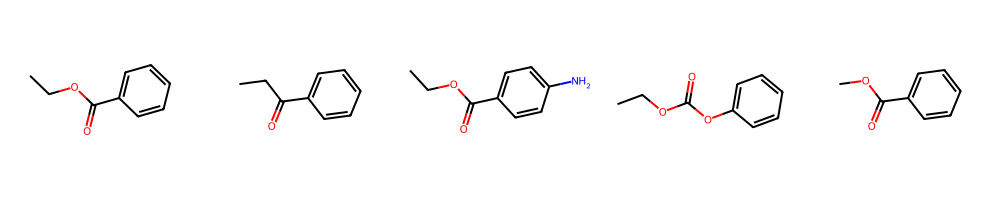

In [47]:
# plot samples
# rdkit draw dff2 smiles and most_similar_smiles
from rdkit.Chem import Draw
from rdkit import Chem

def draw_smiles(smiles_list, size=(200, 200), n=5):
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    return Draw.MolsToGridImage(mols, molsPerRow=n, subImgSize=size)

# draw from clusters
def draw_from_clusters(clusters, cluster_num, df, dff2, size=(200, 200), n=5, num_samples=5):
    smiles_list = []
    if len(clusters) > 0:
        for i in range(min(num_samples, len(clusters))):
            if clusters[cluster_num][i] < len(df):
                smiles_list.append(df.iloc[clusters[cluster_num][i]]['can_smiles_solute'])
            else:
                smiles_list.append(dff2.iloc[(clusters[cluster_num][i]-len(df))]['smiles'])
    print(smiles_list)  
    return draw_smiles(smiles_list, size=size, n=n)

# Draw the frist 5 members of the clusters
draw_from_clusters(clusters, 0, df, dff2, size=(200, 200), n=5)

#### thresh 0.7

In [48]:
distance_threshold = 0.7

clusters7 = Butina.ClusterData(dists, len(combined_fps_rdkit), distance_threshold, isDistData=True)

print(f'Cluster with length 1: {len([cluster for cluster in clusters7 if len(cluster) == 1])}')
print(f'Cluster with length >1: {len([cluster for cluster in clusters7 if len(cluster) >1])}')

# count clusters with lenght 1 that have index > len(rep_train_fps)
single_clusters_test = [cluster for cluster in clusters7 if len(cluster) == 1 and cluster[0] >= len(train_fps)]
print(f'Number of single clusters in test set: {len(single_clusters_test)}')
# count clusters with lenght 1 that have index < len(rep_train_fps)
single_clusters_train = [cluster for cluster in clusters7 if len(cluster) == 1 and cluster[0] < len(train_fps)]
print(f'Number of single clusters in train set: {len(single_clusters_train)}')

Cluster with length 1: 1861
Cluster with length >1: 2533
Number of single clusters in test set: 1701
Number of single clusters in train set: 160


['CCOC(=O)C1=CC=CC=C1', 'CCOC(C)=O', 'CCc1ccccc1', 'COC(=O)c1ccc(Br)cc1', 'COC(=O)c1ccc(I)cc1']


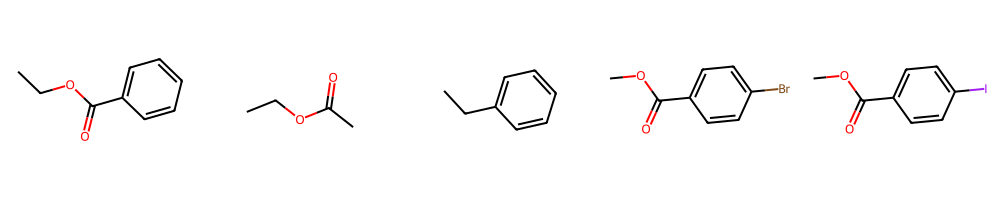

In [49]:
# Draw the frist 5 members of the clusters
draw_from_clusters(clusters7, 0, df, dff2, size=(200, 200), n=5)

### Cluter together - all

In [4]:
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from tqdm import tqdm

def tanimoto_distance(fp1, fp2):
    return 1 - DataStructs.TanimotoSimilarity(fp1, fp2)

def calculate_distance_matrix(fps):
    # Calculate the upper triangle of the distance matrix (excluding diagonal)
    dists = []
    nfps = len(fps)
    for i in tqdm(range(1, nfps), desc="Calculating distance matrix"):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - x for x in sims])
    return dists


def split_into_batches(data, train_fps, batch_size):
    # Concatenate train_fps and test_fps in each batch, keeping train_fps at the front
    return [np.concatenate((train_fps, data[i:i + batch_size]), axis=0) for i in range(0, len(data), batch_size)]




#### sample

In [ ]:
# batch_size = 50000 
batch_size = 1000
distance_threshold = 0.5


# batches = split_into_batches(test_fps[:30000], train_fps, batch_size)
batches = split_into_batches(test_fps[:3000], train_fps, batch_size)



In [ ]:
test_index_single = []
# test_index_single_not_adjust = []

for i, batch in enumerate(batches):
    
    print(f'Processing batch {i+1}/{len(batches)} with {len(batch)} fingerprints')

    batch_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in tqdm(batch, desc="Converting fingerprints to RDKit format")]
    dists = calculate_distance_matrix(batch_rdkit)
    clusters = Butina.ClusterData(dists, len(batch_rdkit), distance_threshold, isDistData=True)
    print(f'Batch {i+1} has {len(clusters)} clusters')
    print(f'Number of clusters with length 1: {len([cluster for cluster in clusters if len(cluster) == 1])}')
    print(f'Number of clusters with length >1: {len([cluster for cluster in clusters if len(cluster) > 1])}')
    print(f'Number of clusters with length 1 in test set: {len([cluster for cluster in clusters if len(cluster) == 1 and cluster[0] >= len(train_fps)])}')
    print(f'Number of clusters with length 1 in train set: {len([cluster for cluster in clusters if len(cluster) == 1 and cluster[0] < len(train_fps)])}')

    # Check for single-member clusters in the test set
    for cluster in clusters:
        if len(cluster) == 1 and cluster[0] >= len(train_fps):
            # test_index_single_not_adjust.append(cluster[0])
            test_index_single.append(cluster[0]+ i * batch_size - len(train_fps))  # Adjust index for batch
            # print(f'Found single-member cluster in test set: {cluster[0]}')
    

print(f'Total single-member clusters in test set: {len(test_index_single)}')

Processing batch 1/3 with 4218 fingerprints


Converting fingerprints to RDKit format:   0%|          | 0/4218 [00:00<?, ?it/s]

Calculating distance matrix: 100%|██████████| 4217/4217 [00:01<00:00, 3466.33it/s] 


Batch 1 has 2457 clusters
Number of clusters with length 1: 1793
Number of clusters with length >1: 664
Number of clusters with length 1 in test set: 450
Number of clusters with length 1 in train set: 1343
Processing batch 2/3 with 4218 fingerprints


Calculating distance matrix: 100%|██████████| 4217/4217 [00:01<00:00, 3599.86it/s] 


Batch 2 has 2317 clusters
Number of clusters with length 1: 1663
Number of clusters with length >1: 654
Number of clusters with length 1 in test set: 364
Number of clusters with length 1 in train set: 1299
Processing batch 3/3 with 4218 fingerprints


Calculating distance matrix: 100%|██████████| 4217/4217 [00:01<00:00, 3500.59it/s] 


Batch 3 has 2303 clusters
Number of clusters with length 1: 1626
Number of clusters with length >1: 677
Number of clusters with length 1 in test set: 348
Number of clusters with length 1 in train set: 1278
Total single-member clusters in test set: 1162


In [135]:
# test_index_single.sort()
print(test_index_single[-15:])  
print(test_index_single_not_adjust[-15:])

[2032, 2025, 2024, 2023, 2022, 2019, 2017, 2016, 2014, 2013, 2010, 2006, 2005, 2002, 2000]
[3250, 3243, 3242, 3241, 3240, 3237, 3235, 3234, 3232, 3231, 3228, 3224, 3223, 3220, 3218]


In [ ]:
# z = zip(test_index_single,test_index_single_not_adjust)
# # print the first 10 pairs
# for i, (a, b) in enumerate(z):
#     print(f'Pair {i+1}: {b} -> {a}')

In [137]:
distance_threshold = 0.5
# find similarity between the single-member clusters in test set
test_fps_single = test_fps[test_index_single]
print(f'Number of single-member clusters in test set: {len(test_fps_single)}')
# Calculate the distance matrix for the single-member clusters
test_fps_single_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in tqdm(test_fps_single, desc="Converting single-member test fingerprints to RDKit format")]
dists_single = calculate_distance_matrix(test_fps_single_rdkit)
# Perform clustering on the single-member clusters
clusters_single = Butina.ClusterData(dists_single, len(test_fps_single_rdkit), distance_threshold, isDistData=True)
print(f'Number of clusters in single-member test set: {len(clusters_single)}')
# Check for single-member clusters in the single-member test set
single_test_index_single = [cluster for cluster in clusters_single if len(cluster) == 1]
print(f'Number of single-member clusters in single-member test set: {len(single_test_index_single)}')



Number of single-member clusters in test set: 1162


Converting single-member test fingerprints to RDKit format: 100%|██████████| 1162/1162 [00:00<00:00, 4609.93it/s]
Calculating distance matrix: 100%|██████████| 1161/1161 [00:00<00:00, 13250.11it/s]

Number of clusters in single-member test set: 1095
Number of single-member clusters in single-member test set: 1036


In [138]:
clusters_single[:10]

((541, 69, 883),
 (534, 938, 1117),
 (477, 986, 1005),
 (468, 843, 914),
 (231, 562, 1075),
 (168, 588, 1024),
 (93, 851, 948),
 (68, 490, 1082),
 (1161, 31),
 (1147, 247))

(1901, 932, 2996)
['C1=CC=C(C=C1)N=NC2=C(C=C(C=C2)N)N', 'C1=CC=C(C=C1)N=NC2=C(N=C(C=C2)N)N', 'CCOC1=CC=C(C=C1)N=NC2=C(C=C(C=C2)N)N']


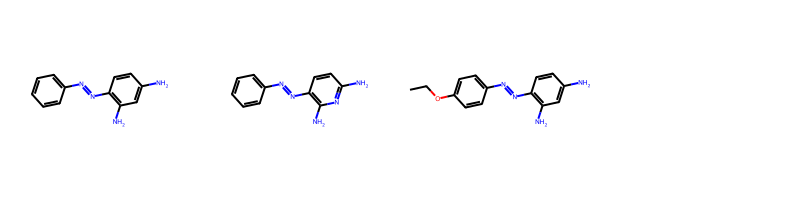

In [139]:
from rdkit.Chem import Draw
from rdkit import Chem

def draw_smiles(smiles_list, size=(200, 200), n=5):
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    return Draw.MolsToGridImage(mols, molsPerRow=n, subImgSize=size)

# draw from clusters
def draw_from_test_clusters(clusters, cluster_num, dff2, size=(200, 200), n=5, num_samples=5):
    smiles_list = []
    if len(clusters) > 0:
        for i in range(min(num_samples, len(clusters))):
            smiles_list.append(dff2.iloc[(clusters[cluster_num][i])]['smiles'])
    print(clusters[cluster_num])
    print(smiles_list)  
    return draw_smiles(smiles_list, size=size, n=n)

# map the indices in clusters_single to the original dff2 indices
# Map clusters_single indices to original dff2 indices using test_index_single
clusters_single_dff2_indices = tuple(
    tuple(test_index_single[idx] for idx in cluster) for cluster in clusters_single
)

# Draw the frist 5 members of the clusters
draw_from_test_clusters(clusters_single_dff2_indices, 0, dff2, size=(200, 200), n=4, num_samples=3)

(728, 1774, 2562)
['CC1=CC(=NO1)C(=O)NNCC2=CC=CC=C2', 'CC1=CC(=NO1)C(=O)NNCC2=CC=C(C=C2)N(C)C', 'CC1=NOC(=C1)C(=O)NNCC2=CC=CC=C2']


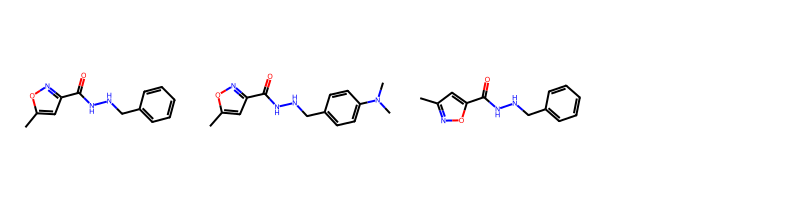

In [140]:
draw_from_test_clusters(clusters_single_dff2_indices, 5, dff2, size=(200, 200), n=4, num_samples=3)

#### all

In [141]:
batch_size = 50000 
distance_threshold = 0.5

batches = split_into_batches(test_fps, train_fps, batch_size)
print("Batch size:", batch_size)
print(f'Number of batches: {len(batches)}')

Batch size: 50000
Number of batches: 13


In [142]:
test_index_single = []
# test_index_single_not_adjust = []

for i, batch in enumerate(batches):
    
    print(f'Processing batch {i+1}/{len(batches)} with {len(batch)} fingerprints')

    batch_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in tqdm(batch, desc="Converting fingerprints to RDKit format")]
    dists = calculate_distance_matrix(batch_rdkit)
    clusters = Butina.ClusterData(dists, len(batch_rdkit), distance_threshold, isDistData=True)
    print(f'Batch {i+1} has {len(clusters)} clusters')
    print(f'Number of clusters with length 1: {len([cluster for cluster in clusters if len(cluster) == 1])}')
    print(f'Number of clusters with length >1: {len([cluster for cluster in clusters if len(cluster) > 1])}')
    print(f'Number of clusters with length 1 in test set: {len([cluster for cluster in clusters if len(cluster) == 1 and cluster[0] >= len(train_fps)])}')
    print(f'Number of clusters with length 1 in train set: {len([cluster for cluster in clusters if len(cluster) == 1 and cluster[0] < len(train_fps)])}')

    # Check for single-member clusters in the test set
    for cluster in clusters:
        if len(cluster) == 1 and cluster[0] >= len(train_fps):
            # test_index_single_not_adjust.append(cluster[0])
            test_index_single.append(cluster[0]+ i * batch_size - len(train_fps))  # Adjust index for batch
            # print(f'Found single-member cluster in test set: {cluster[0]}')
    
    # Write to file after each batch
    with open('test_index_single.txt', 'a') as f:
        for idx in test_index_single:
            f.write(f"{idx}\n")
    test_index_single.clear()

Processing batch 1/13 with 53218 fingerprints


Calculating distance matrix: 100%|██████████| 53217/53217 [03:08<00:00, 283.07it/s] 


Batch 1 has 19568 clusters
Number of clusters with length 1: 12231
Number of clusters with length >1: 7337
Number of clusters with length 1 in test set: 11256
Number of clusters with length 1 in train set: 975
Processing batch 2/13 with 53218 fingerprints


Calculating distance matrix: 100%|██████████| 53217/53217 [03:19<00:00, 267.32it/s] 


Batch 2 has 19289 clusters
Number of clusters with length 1: 11441
Number of clusters with length >1: 7848
Number of clusters with length 1 in test set: 10316
Number of clusters with length 1 in train set: 1125
Processing batch 3/13 with 53218 fingerprints


...

Batch 11 has 12245 clusters
Number of clusters with length 1: 6162
Number of clusters with length >1: 6083
Number of clusters with length 1 in test set: 4853
Number of clusters with length 1 in train set: 1309
Processing batch 12/13 with 53218 fingerprints


Calculating distance matrix: 100%|██████████| 53217/53217 [03:15<00:00, 271.64it/s] 


Batch 12 has 27680 clusters
Number of clusters with length 1: 18900
Number of clusters with length >1: 8780
Number of clusters with length 1 in test set: 17674
Number of clusters with length 1 in train set: 1226
Processing batch 13/13 with 38430 fingerprints


Calculating distance matrix: 100%|██████████| 38429/38429 [01:38<00:00, 388.35it/s] 


Batch 13 has 21165 clusters
Number of clusters with length 1: 15331
Number of clusters with length >1: 5834
Number of clusters with length 1 in test set: 14149
Number of clusters with length 1 in train set: 1182


In [5]:
# Read the indices from the file
with open('test_index_single.txt', 'r') as f:
    test_index_single = [int(line.strip()) for line in f.readlines()]
    
print(f'Total single-member clusters in test set: {len(test_index_single)}')

Total single-member clusters in test set: 159077


In [6]:
distance_threshold = 0.5
# find similarity between the single-member clusters in test set
test_fps_single = test_fps[test_index_single]
print(f'Number of single-member clusters in test set: {len(test_fps_single)}')



Number of single-member clusters in test set: 159077


In [7]:

# Split test_fps_single into 3 batches of 60000 each
batch_size = 54000
cluster_not_single = []
test_fps_single_batches = [test_fps_single[i:i + batch_size] for i in range(0, len(test_fps_single), batch_size)]
for idx, batch in enumerate(test_fps_single_batches):
    print(f"Batch {idx+1}: {len(batch)} fingerprints")

    # Calculate the distance matrix for the single-member clusters
    batch_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in tqdm(batch, desc="Converting single-member test fingerprints to RDKit format")]
    dists_single = calculate_distance_matrix(batch_rdkit)
    # Perform clustering on the single-member clusters
    clusters_single = Butina.ClusterData(dists_single, len(batch_rdkit), distance_threshold, isDistData=True)
    print(f'Number of clusters in single-member test set: {len(clusters_single)}')
    print(f'Number of clusters with length 1: {len([cluster for cluster in clusters_single if len(cluster) == 1])}')
    print(f'Number of clusters with length >1: {len([cluster for cluster in clusters_single if len(cluster) > 1])}')

    # adjust clusters_single indices to the original test_fps_single indices
    clusters_single_dff2_indices = tuple(
        tuple(test_index_single[i+idx*batch_size] for i in cluster) 
              for cluster in clusters_single if len(cluster) > 1
    )
    
    cluster_not_single.extend(clusters_single_dff2_indices)
   

Batch 1: 54000 fingerprints


Converting single-member test fingerprints to RDKit format: 100%|██████████| 54000/54000 [00:10<00:00, 5031.37it/s]
Calculating distance matrix: 100%|██████████| 53999/53999 [03:22<00:00, 266.55it/s] 


Number of clusters in single-member test set: 42183
Number of clusters with length 1: 34686
Number of clusters with length >1: 7497
Batch 2: 54000 fingerprints


Converting single-member test fingerprints to RDKit format: 100%|██████████| 54000/54000 [00:11<00:00, 4831.15it/s]
Calculating distance matrix: 100%|██████████| 53999/53999 [03:21<00:00, 267.63it/s] 


Number of clusters in single-member test set: 45167
Number of clusters with length 1: 38932
Number of clusters with length >1: 6235
Batch 3: 51077 fingerprints


Converting single-member test fingerprints to RDKit format: 100%|██████████| 51077/51077 [00:25<00:00, 2009.84it/s]
Calculating distance matrix: 100%|██████████| 51076/51076 [02:53<00:00, 294.49it/s] 


Number of clusters in single-member test set: 43613
Number of clusters with length 1: 38330
Number of clusters with length >1: 5283


In [10]:
print(len(cluster_not_single))
len_cluster_not_single = [len(cluster) for cluster in cluster_not_single]
print("unique cluster sizes:", set(len_cluster_not_single))


19015
unique cluster sizes: {2, 3, 4, 5, 6, 7, 8, 9}


In [46]:
# print cluster with size 9
for cluster in cluster_not_single:
    if len(cluster) == 8:
        print(cluster)

(244539, 22366, 20950, 59178, 63318, 61817, 59220, 116777)
(108257, 60532, 95506, 193564, 164795, 203404, 247572, 247267)
(122686, 40395, 18456, 58367, 59026, 193039, 241967, 200720)
(55709, 14614, 4310, 193223, 163930, 160689, 183756, 244003)
(72803, 31797, 26060, 147841, 114156, 101397, 160625, 195900)
(21024, 76116, 52098, 99272, 117795, 175328, 168198, 238581)
(12614, 98614, 96921, 133635, 118956, 193334, 156517, 224327)
(6325, 79683, 122485, 116752, 199025, 188563, 158153, 150146)
(2961, 54312, 136542, 125343, 111123, 151736, 236641, 201911)
(251506, 204568, 342736, 391378, 391386, 377769, 356068, 351867)
(241328, 259578, 258053, 251465, 250785, 316428, 311791, 370270)


In [27]:
large_cluster = [cluster for cluster in cluster_not_single if len(cluster) > 6]
print(len(large_cluster))

36


(74065, 38206, 1353, 106639, 147550, 132500, 133652, 178646, 150038)
['CNC(=O)C1=CC2=CC=CC=C2C=C1O', 'CNC(=O)C1=C(C=C(C=C1)C2=CC=CC=C2)O', 'COC1=C(C=CC(=C1)C2=CC(=C(C=C2)NC(=O)C3=CC4=CC=CC=C4C=C3O)OC)NC(=O)C5=CC6=CC=CC=C6C=C5O', 'CNC(=O)C1=CC2=CC=CC=C2C(=C1)O', 'CNC(=O)C1=C(C=CC(=C1)C=O)O']


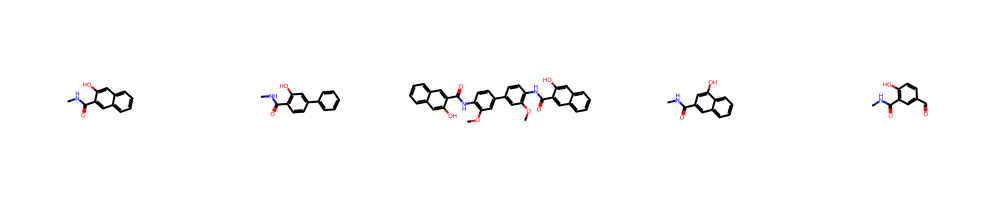

In [ ]:
from rdkit.Chem import Draw
from rdkit import Chem

def draw_smiles(smiles_list, size=(200, 200), n=5):
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    return Draw.MolsToGridImage(mols, molsPerRow=n, subImgSize=size)

# draw from clusters
def draw_from_test_clusters(clusters, cluster_num, dff2, size=(200, 200), n=5, num_samples=5):
    smiles_list = []
    if len(clusters) > 0:
        for i in range(min(num_samples, len(clusters))):
            smiles_list.append(dff2.iloc[(clusters[cluster_num][i])]['smiles'])
    print(clusters[cluster_num])
    print(smiles_list)  
    return draw_smiles(smiles_list, size=size, n=n)

# map the indices in clusters_single to the original dff2 indices
# Map clusters_single indices to original dff2 indices using test_index_single
clusters_single_dff2_indices = tuple(
    tuple(test_index_single[idx] for idx in cluster) for cluster in clusters_single
)

# Draw the frist 5 members of the clusters
draw_from_test_clusters(large_cluster, 0, dff2, size=(200, 200), n=5, num_samples=5)


(244539, 22366, 20950, 59178, 63318, 61817, 59220, 116777)
['B(C1=CC=CC=C1B(O)O)(O)O', 'B(C1=CC=CC2=CC=CC=C12)(O)O', 'B(C1=CC=CC=C1C=CC2=CC=CC=C2B(O)O)(O)O', 'B(C1=CC=CC=C1C(=O)C)(O)O', 'B(C1=C2C3=CC=CC=C3C2=CC=C1)(O)O']


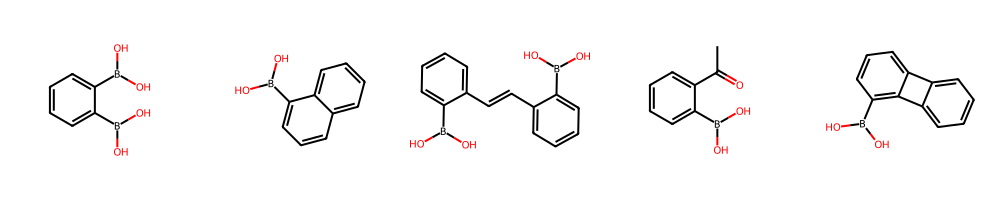

In [29]:
draw_from_test_clusters(large_cluster, 1, dff2, size=(200, 200), n=5, num_samples=5)


(108257, 60532, 95506, 193564, 164795, 203404, 247572, 247267)
['C1=CC=C(C=C1)C2=CC(=C(C=C2)Cl)F', 'C1=CC(=CC(=C1)S)C2=CC(=C(C=C2)Cl)F', 'C=CC1=C(C=C(C=C1)C2=CC=CC=C2)F', 'C1=CC=C(C=C1)C2=CC(=C(C=C2Cl)Cl)F', 'C1=CC=C(C=C1)C2=C(C=C(C=C2F)Cl)F']


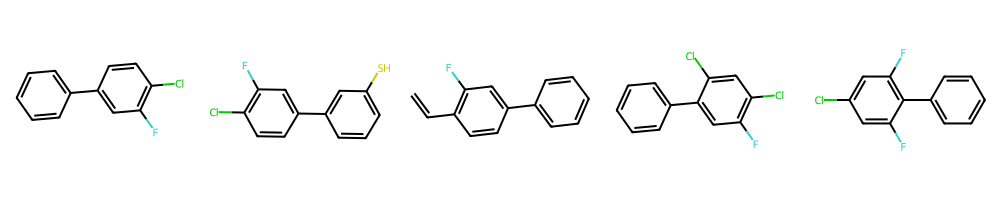

In [30]:
draw_from_test_clusters(large_cluster, 2, dff2, size=(200, 200), n=5, num_samples=5)

(122686, 40395, 18456, 58367, 59026, 193039, 241967, 200720)
['CCCOC1=C(C=C(C=C1)C)[N+](=O)[O-]', 'COCCOC1=C(C=C(C=C1)C=O)[N+](=O)[O-]', 'CCC(C)(C)C1=CC(=C(C=C1)OCCO)[N+](=O)[O-]', 'CCCOC1=C(C=C(C=C1)NC(=O)C)[N+](=O)[O-]', 'CC1=CC(=C(C=C1)OC(C)CC(=O)O)[N+](=O)[O-]']


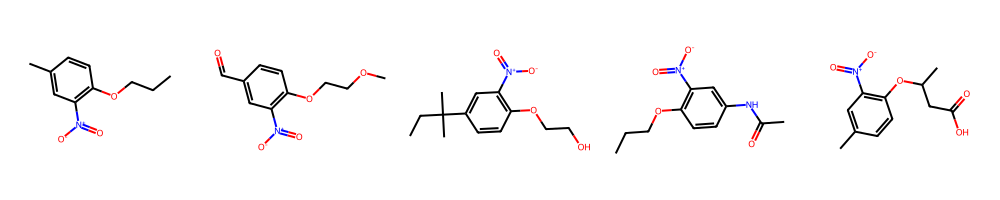

In [31]:
draw_from_test_clusters(large_cluster, 3, dff2, size=(200, 200), n=5, num_samples=5)

(55709, 14614, 4310, 193223, 163930, 160689, 183756, 244003)
['CC(=O)C(CC1=CC=C(C=C1)Cl)C(=O)C', 'CC(=O)C(CC1=CC(=C(C=C1)O)OC)C(=O)C', 'COC(=O)C(CC1=CC=C(C=C1)Cl)Cl', 'CC(=O)C(CC1=CC2=C(C=C1)OCO2)C(=O)C', 'CC(=O)C(C1=CC=C(C=C1)Cl)O']


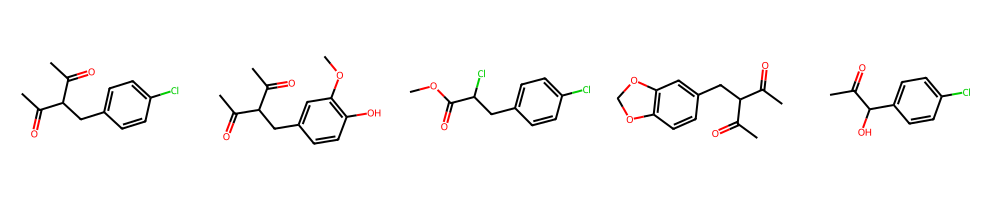

In [32]:
draw_from_test_clusters(large_cluster, 4, dff2, size=(200, 200), n=5, num_samples=5)

(21024, 76116, 52098, 99272, 117795, 175328, 168198, 238581)
['CC(C)(C)N1C(=O)C2=CC=CC=C2C1=O', 'CC(C)(C)N1C(=O)C2=C(C1=O)C(=CC=C2)N', 'CC(C)(C)SN1C(=O)C2=CC=CC=C2C1=O', 'CC(C)(C)N1CC(=C)C2=CC=CC=C2C1=O', 'CC(C)(C#C)N1C(=O)C2=CC=CC=C2C1=O']


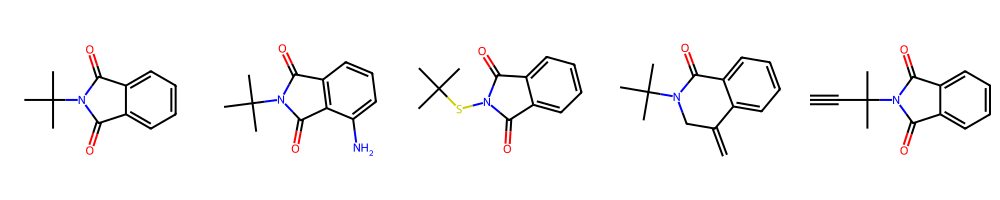

In [33]:
draw_from_test_clusters(large_cluster, 6, dff2, size=(200, 200), n=5, num_samples=5)

(12614, 98614, 96921, 133635, 118956, 193334, 156517, 224327)
['CC(=O)C(C(=O)NC1=CC=CC=C1)Cl', 'C1=CC=C(C=C1)NC(=O)C(C#N)C#N', 'CC(C)(C)C(=O)C(C(=O)NC1=CC=CC=C1)F', 'CCCCC(C(=O)C)C(=O)NC1=CC=CC=C1', 'CC(C)C(=O)C(C(=O)NC1=CC=CC=C1)F']


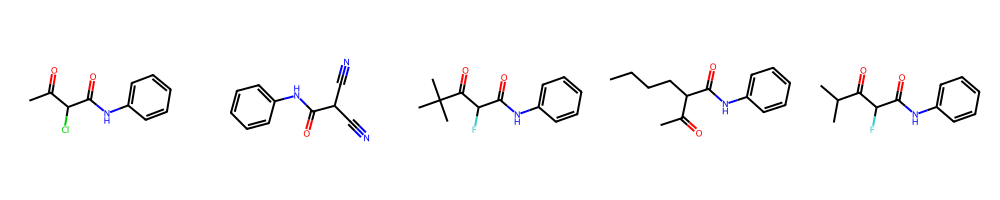

In [34]:
draw_from_test_clusters(large_cluster, 7, dff2, size=(200, 200), n=5, num_samples=5)

(6325, 79683, 122485, 116752, 199025, 188563, 158153, 150146)
['C1=CC=C(C=C1)C2=CC=C(O2)C3=CC=CC=C3', 'C1=CN=CC=C1C2=CC=C(O2)C3=CC=NC=C3', 'CC(C)C1=CC=C(OC1=O)C2=CC=CC=C2', 'C1=CC=C(C=C1)C2=CC=C(O2)C=C(Cl)Cl', 'C1=CC=C(C=C1)C2=CC=C(O2)C3=NC=CN3']


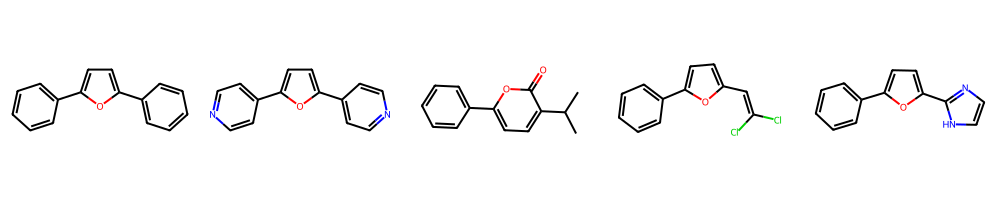

In [35]:
draw_from_test_clusters(large_cluster, 8, dff2, size=(200, 200), n=5, num_samples=5)

(2961, 54312, 136542, 125343, 111123, 151736, 236641, 201911)
['C1=CC=C2C(=C1)C=CC3=CC=CC=C3C2=O', 'C1=CC=C2C(=C1)C=CC3=C(C2=O)C=CC=N3', 'C1=CC=C2C(=C1)C=CC3=C(C2=O)C=C(C=C3)Cl', 'C1=CC=C2C(=C1)C=C(C3=CC=CC=C3C2=O)F', 'C1=CC=C2C(=C1)C=CC3=CC=CC=C3C2=N']


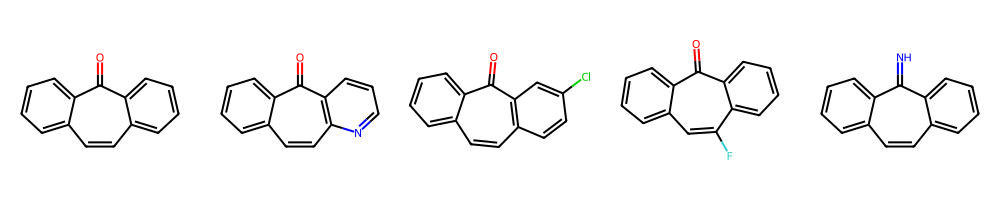

In [36]:
draw_from_test_clusters(large_cluster, 9, dff2, size=(200, 200), n=5, num_samples=5)

(115133, 43826, 81180, 188312, 229601, 229612, 229594)
['C1=CC(=CC=C1/C=C/C(=O)O)C2=CC=C(C=C2)O', 'C1=CC(=CC=C1C=CC=CC(=O)O)O', 'C1=CC(=CC=C1/C=C/C=C\\C(=O)O)O', 'C1=CN(C=C1)C2=CC=C(C=C2)/C=C/C(=O)O', 'C1=CC(=CC=C1/C=C/C(=O)O)C2=COC=C2']


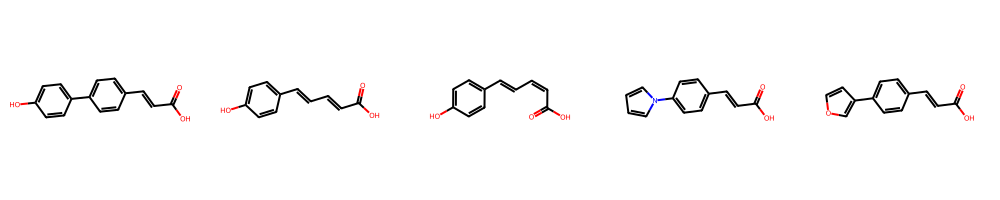

In [43]:
draw_from_test_clusters(large_cluster, 15, dff2, size=(200, 200), n=5, num_samples=5)

In [ ]:
for i in range(0,15):
    print(dff2.iloc[large_cluster[i][0]]['smiles'])

# this list is saved to file: Molecules_for_UQ.smi


CNC(=O)C1=CC2=CC=CC=C2C=C1O
B(C1=CC=CC=C1B(O)O)(O)O
C1=CC=C(C=C1)C2=CC(=C(C=C2)Cl)F
CCCOC1=C(C=C(C=C1)C)[N+](=O)[O-]
CC(=O)C(CC1=CC=C(C=C1)Cl)C(=O)C
CCOC(=O)C1C(=O)C2=CC=CC=C2O1
CC(C)(C)N1C(=O)C2=CC=CC=C2C1=O
CC(=O)C(C(=O)NC1=CC=CC=C1)Cl
C1=CC=C(C=C1)C2=CC=C(O2)C3=CC=CC=C3
C1=CC=C2C(=C1)C=CC3=CC=CC=C3C2=O
CCCC(=C(C#N)C#N)N
CC(=O)C1=CC=CC=C1N=C=S
C1=CC=C2C(=C1)C3=CSC=C3C(=O)N2
C1CC12C3=CC=CC=C3C(=O)O2
CC1C2=CC=CC=C2C=C1C(=O)O


In [ ]:
# write to file


### [Deprecated] Cluster separately then compare

#### train_fps

In [15]:
# Butina clustering of train_fps
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from tqdm import tqdm

def tanimoto_distance(fp1, fp2):
    return 1 - DataStructs.TanimotoSimilarity(fp1, fp2)

def calculate_distance_matrix(fps):
    # Calculate the upper triangle of the distance matrix (excluding diagonal)
    dists = []
    nfps = len(fps)
    for i in tqdm(range(1, nfps), desc="Calculating distance matrix"):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - x for x in sims])
    return dists

train_fps_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in train_fps]
dists = calculate_distance_matrix(train_fps_rdkit)
clusters = Butina.ClusterData(dists, len(train_fps_rdkit), distance_threshold, isDistData=True)

# Print the number of clusters and their sizes
print(f'Number of clusters: {len(clusters)}')
# for i, cluster in enumerate(clusters):
#     print(f'Cluster {i}: {len(cluster)} molecules')
# Get the representative molecule for each cluster
representatives = [df.iloc[cluster[0]]['solute'] for cluster in clusters]
print(f'Representative molecules: {representatives[:10]}')  # Print first 10 representatives
rep_train_fps = [train_fps_rdkit[i] for i in [cluster[0] for cluster in clusters]]

Calculating distance matrix: 100%|█████████████████████████████████████████| 3242/3242 [00:01<00:00, 2031.91it/s]


Number of clusters: 1898
Representative molecules: ['CCCCCCCCCCCCCCCCCCCCCCCCCCCC', 'CCCCCCCCCCCCC(O)=O', 'CCCCCC(OCC)=O', 'COC(=O)c1ccccc1', 'O=N(=O)c1ccc(cc1)N(=O)=O', 'CCCCCCC(C)OC(CCCCC)=O', 'OCCCCCCCO', 'CCCCCCCCCCOC(C)=O', 'C1=CC(=CC=C1C(=O)O)O', 'Oc1cc(ccc1)N(=O)=O']


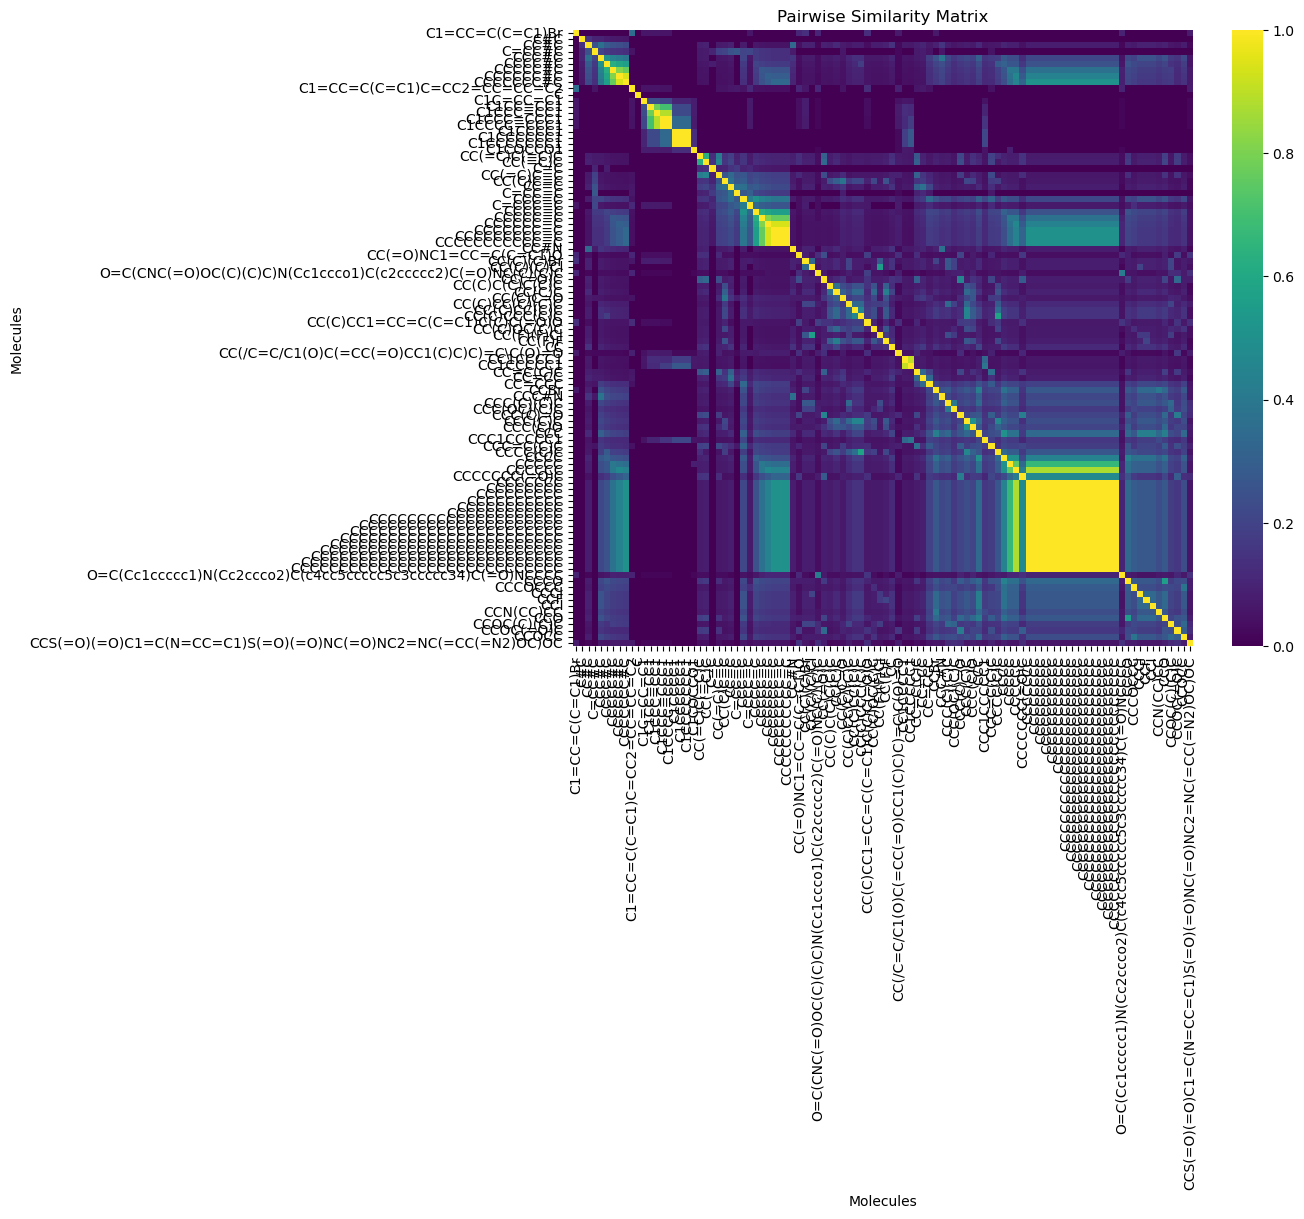

In [ ]:
"""
# plot pairwwise similarity matrix for the first 100 molecules
import seaborn as sns
import matplotlib.pyplot as plt
def plot_similarity_matrix(fps, labels):
    n = len(fps)
    similarity_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                similarity_matrix[i, j] = DataStructs.TanimotoSimilarity(
                    DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fps[i]))),
                    DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fps[j])))
                )
            else:
                similarity_matrix[i, j] = 1.0  # Similarity with itself is 1.0
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity_matrix, annot=False, cmap='viridis', xticklabels=labels, yticklabels=labels)
    plt.title('Pairwise Similarity Matrix')
    plt.xlabel('Molecules')
    plt.ylabel('Molecules')
    plt.show()

# Plot the similarity matrix for the first 100 molecules
train_fps_small = train_fps[:100]
plot_similarity_matrix(train_fps_small[:100], df['solute'][:100])
"""

#### test_fps

In [16]:
test_fps_small = test_fps[:10000]

# test_fps_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in test_fps]
test_fps_rdkit = [DataStructs.cDataStructs.CreateFromBitString(''.join(map(str, fp))) for fp in test_fps_small]
dists = calculate_distance_matrix(test_fps_rdkit)


Calculating distance matrix: 100%|██████████████████████████████████████████| 9999/9999 [00:14<00:00, 676.00it/s]


In [19]:
clusters_test = Butina.ClusterData(dists, len(test_fps_rdkit), distance_threshold, isDistData=True)

# Print the number of clusters and their sizes
print(f'Number of clusters: {len(clusters_test)}')
# for i, cluster in enumerate(clusters_test):
#     print(f'Cluster {i}: {len(cluster)} molecules')
# Get the representative molecule for each cluster
# representatives = [df.iloc[cluster[0]]['solute'] for cluster in clusters_test]
# print(f'Representative molecules: {representatives[:10]}')  # Print first 10 representatives
rep_test_fps = [test_fps_rdkit[i] for i in [cluster[0] for cluster in clusters_test]]

Number of clusters: 4138


#### Compare train and test cluster

With Butina cluster, the threshold is with respect to the cluster center.

What I'm trying to compare the cluster centers of the test and train dataset by clustering them via distance. If the cluster centers could not be clustered (size=1), then those from the test set are more or less OOD data.
However, since the distance is only repect to the cluster center. This means that in the same cluster, there can be two molecules that have great distance, e.g., max 1 for threshold of 0.5.

In [27]:

combined_rep_fps = rep_train_fps + rep_test_fps
dists = calculate_distance_matrix(combined_rep_fps)
# combined_clusters = Butina.ClusterData(dists, len(combined_rep_fps), distance_threshold, isDistData=True)
combined_clusters = Butina.ClusterData(dists, len(combined_rep_fps), 0.5, isDistData=True)

# # plot the distribution of cluster sizes
# import matplotlib.pyplot as plt
# cluster_sizes = [len(cluster) for cluster in combined_clusters]
# plt.figure(figsize=(10, 6))
# plt.hist(cluster_sizes, bins=30, edgecolor='black', alpha=0.7)
# plt.title('Distribution of Cluster Sizes')
# plt.xlabel('Cluster Size')
# plt.ylabel('Frequency')
# plt.grid()
# plt.show()



Calculating distance matrix: 100%|██████████████████████████████████████████| 6035/6035 [00:06<00:00, 979.50it/s]


In [28]:
print(len(rep_train_fps), len(rep_test_fps), len(combined_rep_fps))
print('cluster index of test_fps start from', len(rep_train_fps))

1898 4138 6036
cluster index of test_fps start from 1898


In [29]:
print(f'Cluster with length 1: {len([cluster for cluster in combined_clusters if len(cluster) == 1])}')
print(f'Cluster with length >1: {len([cluster for cluster in combined_clusters if len(cluster) >1])}')

Cluster with length 1: 4936
Cluster with length >1: 437


In [32]:
combined_clusters[0:2]

((3, 1898, 1900, 1908, 1909, 1914, 1944, 2068, 2152, 2194, 2249, 2496, 2498),
 (118, 1905, 1910, 1923, 1931, 2137, 2163, 2282))

In [33]:
# count clusters with lenght 1 that have index > len(rep_train_fps)
single_clusters_test = [cluster for cluster in combined_clusters if len(cluster) == 1 and cluster[0] >= len(rep_train_fps)]
print(f'Number of single clusters in test set: {len(single_clusters_test)}')
# count clusters with lenght 1 that have index < len(rep_train_fps)
single_clusters_train = [cluster for cluster in combined_clusters if len(cluster) == 1 and cluster[0] < len(rep_train_fps)]
print(f'Number of single clusters in train set: {len(single_clusters_train)}')

Number of single clusters in test set: 3500
Number of single clusters in train set: 1436


# Output distribution

In [5]:
dfdmf_train = pd.read_csv('/home/nanta/Solv_GNN_SSD/data/DMF_as_solvent/Solv_GNN_SSD_train_DMF_as_solvent.csv')
print(dfdmf_train.shape)
print(dfdmf_train.columns)


(3218, 15)
Index(['solute', 'solvent', 'logS', 'DGsolv', 'Reference (DOI)', 'Comments',
       'can_smiles_solute', 'can_smiles_solvent', 'concat_smiles',
       'is_chonps_halogens', 'index', 'DGsolv_cosmo',
       'Atom_bond_type_overlap_with_exp', 'AE', 'Signed_Err'],
      dtype='object')


In [11]:
dfdmf_train.loc[200:203]

,solute,solvent,logS,DGsolv,Reference (DOI),Comments,can_smiles_solute,can_smiles_solvent,concat_smiles,is_chonps_halogens,index,DGsolv_cosmo,Atom_bond_type_overlap_with_exp,AE,Signed_Err
200,ClCc1ccc(C)cc1C,CN(C)C=O,NaN,-7.989686,NaN,NaN,Cc1ccc(CCl)c(C)c1,CN(C)C=O,Cc1ccc(CCl)c(C)c1.CN(C)C=O,NaN,453378,-8.007978,Y,0.018293,0.018293
201,OC(=O)c1ccccc1N,CN(C)C=O,NaN,-13.366380,NaN,NaN,Nc1ccccc1C(=O)O,CN(C)C=O,Nc1ccccc1C(=O)O.CN(C)C=O,NaN,547832,-13.384711,Y,0.018331,0.018331
202,CCCC(O)C(C)C,CN(C)C=O,NaN,-6.790044,NaN,NaN,CCCC(O)C(C)C,CN(C)C=O,CCCC(O)C(C)C.CN(C)C=O,NaN,277721,-6.770179,Y,0.019865,-0.019865
203,N#CCc(cc1)ccc1C,CN(C)C=O,NaN,-9.856749,NaN,NaN,Cc1ccc(CC#N)cc1,CN(C)C=O,Cc1ccc(CC#N)cc1.CN(C)C=O,NaN,682736,-9.836757,Y,0.019992,-0.019992


In [2]:
# deploymnet data
dff2 = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter2.csv.gz', compression='gzip')
print(dff2.shape)

/tmp/ipykernel_834252/2506275508.py:2: DtypeWarning: Columns (32,39) have mixed types. Specify dtype option on import or set low_memory=False.
  dff2 = pd.read_csv('/home/nanta/Redox_mediator_screening/data/Filtered_data/filter2.csv.gz', compression='gzip')


(635212, 49)


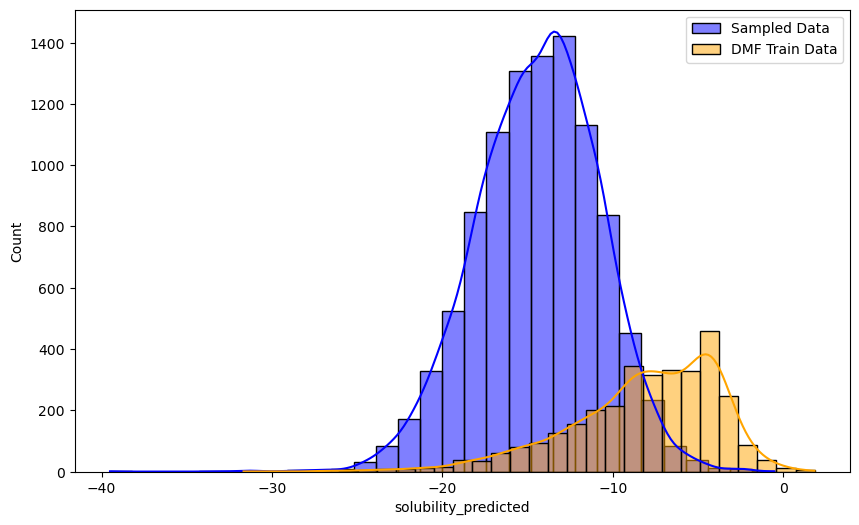

In [18]:
# sample 1000 molecules from dff2
dff2_sample = dff2.sample(n=10000, random_state=42).reset_index(drop=True)

# plot distribution of 'solubility_predicted'
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(dff2_sample['solubility_predicted'], bins=30, kde=True, color='blue', label='Sampled Data', alpha=0.5)
sns.histplot(dfdmf_train['DGsolv'], bins=30, kde=True, color='orange', label='DMF Train Data', alpha=0.5)
plt.legend()
plt.show()

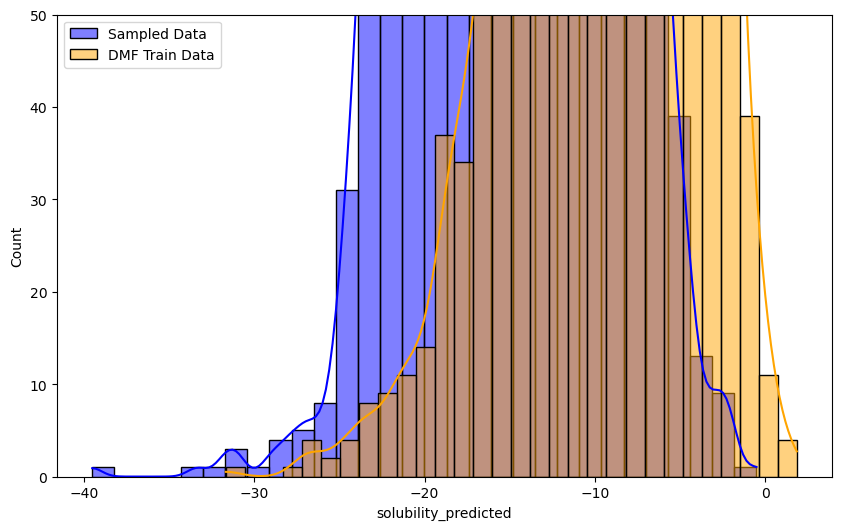

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(dff2_sample['solubility_predicted'], bins=30, kde=True, color='blue', label='Sampled Data', alpha=0.5)
sns.histplot(dfdmf_train['DGsolv'], bins=30, kde=True, color='orange', label='DMF Train Data', alpha=0.5)
plt.legend()
plt.ylim([0, 50])
plt.show()

In [30]:
# data from molecules not similar to DMF train data
# Simirity using Tanimoto distance

# Read the indices from the file
with open('test_index_single.txt', 'r') as f:
    test_index_single = [int(line.strip()) for line in f.readlines()]

df_notsim = dff2.loc[test_index_single]
print(df_notsim.shape)

(159077, 49)


In [32]:
df_notsim.loc[74065]['smiles']

'CNC(=O)C1=CC2=CC=CC=C2C=C1O'

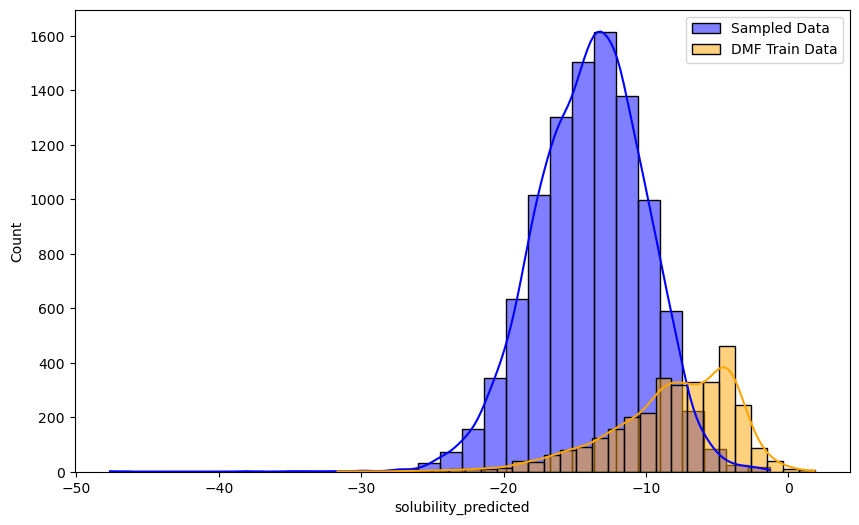

In [ ]:
df_notsim_sample = df_notsim.sample(n=10000, random_state=42).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.histplot(df_notsim_sample['solubility_predicted'], bins=30, kde=True, color='blue', label='Sampled Data', alpha=0.5)
sns.histplot(dfdmf_train['DGsolv'], bins=30, kde=True, color='orange', label='DMF Train Data', alpha=0.5)
plt.legend()

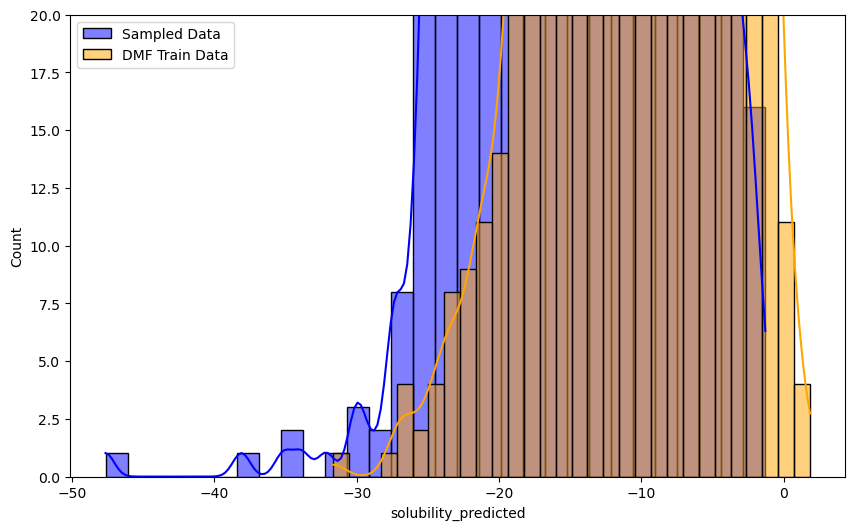

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df_notsim_sample['solubility_predicted'], bins=30, kde=True, color='blue', label='Sampled Data', alpha=0.5)
sns.histplot(dfdmf_train['DGsolv'], bins=30, kde=True, color='orange', label='DMF Train Data', alpha=0.5)
plt.ylim([0, 20])
plt.legend()

# 5-NN tanimoto distance

In [ ]:
# 5-NN tanimoto distance
from sklearn.neighbors import NearestNeighbors
